# Imports

In [2]:
import numpy as np
import sympy as sp
from numba import njit

Mis funciones definidas en `/code/src/`

In [3]:
import sys
import os

# Navigate up to the 'code' directory, then into 'src'
sys.path.append(os.path.abspath('../src'))

# Import the functions
from dynamics import generate_orbit, generate_escape_time_fractal, generate_fatou_basins, generate_fatou_basins_and_times, make_generate_orbit_jitted, make_generate_escape_time_fractal_jitted, make_generate_fatou_basins_jitted, make_generate_fatou_basins_and_times_jitted
from utils import DynamicsPlotter

# Default settings

In [4]:
horizontal_pixels = 10000
vertical_pixels = 10000

max_iter = 1e3

tolerance = 1e-6
infinity_threshold = 1e10

julia_thickness = max(1, int(horizontal_pixels/2000))

# Chapter 1: Introducción

## Section 2: Polinomios de grado dos

### $P(z) = z^2$

In [12]:
@njit
def Rz2(z):
    return z**2

generate_fatou_basins_and_times_jitted = make_generate_fatou_basins_and_times_jitted(Rz2)

In [13]:
center = 0.0
max_distance_to_center = 2

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

attractors = np.array([0, complex(np.inf, 0)], dtype=np.complex128)

basins, times = generate_fatou_basins_and_times_jitted(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, attractors, max_iter=max_iter, tolerance=tolerance, infinity_threshold=infinity_threshold)

<Axes: >

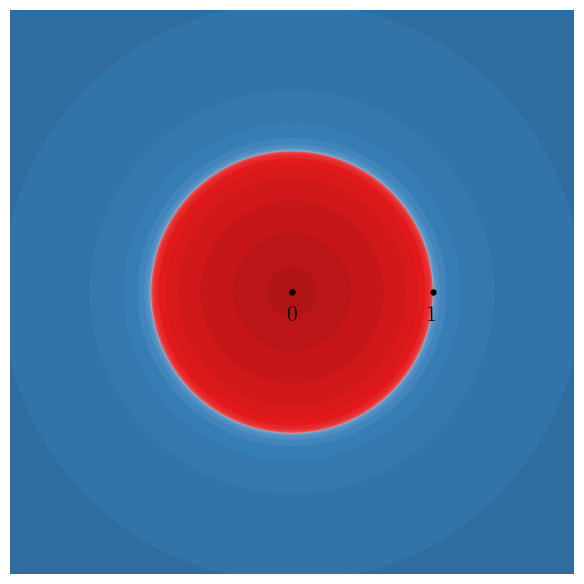

In [14]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)
# Plot 1: The solid colored basins
fig, ax = plotter.plot_fatou_basins_shaded(basins, times, shading_power=0.6, title="", show_axis=False, show_axis_labels=False)
plotter.add_points(ax, [attractors[0]], label="$0$")
plotter.add_points(ax, [1], label="$1$")

In [ ]:
plotter.save_figure(fig, "../../figures/z_squared_fatou_basins_and_times.pdf")

### La familia cuadrática $z^2 + c$

#### $P_{-1}(z) = z^2 - 1$

In [239]:
@njit
def Rz2m1(z):
    return z**2 - 1

generate_escape_time_fractal_jitted = make_generate_escape_time_fractal_jitted(Rz2m1)
generate_fatou_basins_and_times_jitted = make_generate_fatou_basins_and_times_jitted(Rz2m1)

In [240]:
center = 0.0
max_distance_to_center = 2

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

attractors = np.array([0, complex(np.inf, 0)], dtype=np.complex128)

In [241]:
modified_max_iter = 256
modified_infinity_threshold=2.0

times = generate_escape_time_fractal_jitted(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=modified_max_iter, infinity_threshold=modified_infinity_threshold)

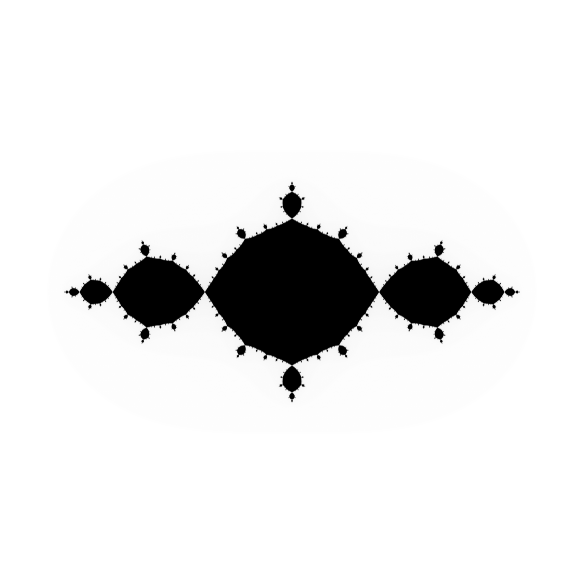

In [242]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)
fig, ax = plotter.plot_escape_time_fractal(times, title="", show_axis=False, show_axis_labels=False)

In [243]:
plotter.save_figure(fig, "../../figures/z_squared_minus_one_escape_times.pdf")

Saved figure to: ../../figures/z_squared_minus_one_escape_times.pdf


#### Descartadas

In [ ]:
basins, times = generate_fatou_basins_and_times_jitted(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, attractors, max_iter=max_iter, tolerance=tolerance, infinity_threshold=infinity_threshold)

<Axes: >

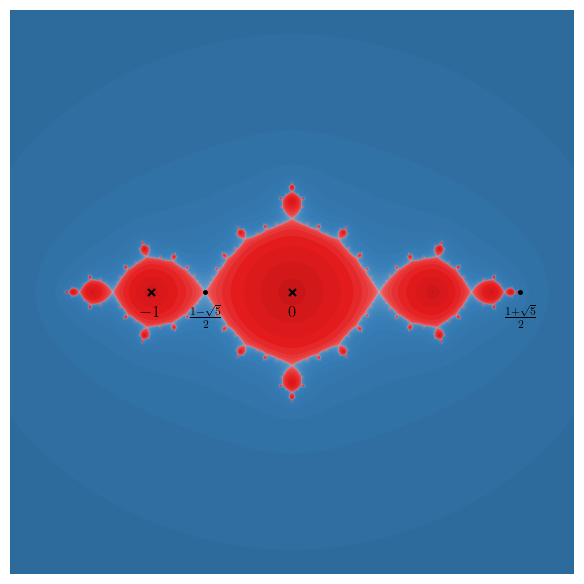

In [17]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)
# Plot 1: The solid colored basins
fig, ax = plotter.plot_fatou_basins_shaded(basins, times, title="", shading_power=0.4, show_axis=False, show_axis_labels=False)
plotter.add_points(ax, [attractors[0]], label="$0$", marker="x", s=25, fontsize=12)
plotter.add_points(ax, [-1], label="$-1$", marker="x", s=25, fontsize=12)
plotter.add_points(ax, [(1 + np.sqrt(5))/2], label=r"$\frac{1 + \sqrt{5}}{2}$", s=25, fontsize=12)
plotter.add_points(ax, [(1 - np.sqrt(5))/2], label=r"$\frac{1 - \sqrt{5}}{2}$", s=25, fontsize=12)

In [ ]:
plotter.save_figure(fig, "../../figures/z_squared_minus_one_fatou_basins_and_times.pdf")

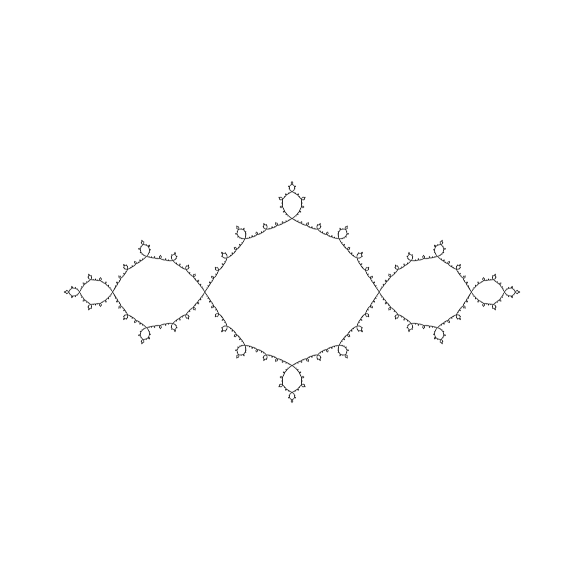

In [ ]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)
fig, ax = plotter.plot_julia_set_from_basins(basins, thickness=julia_thickness, title="", show_axis=False, show_axis_labels=False)

In [24]:
plotter.save_figure(fig, "../../figures/z_squared_minus_one_julia_set.pdf")

Saved figure to: ../../figures/z_squared_minus_one_julia_set.pdf


In [ ]:
modified_ymin = center.imag-max_distance_to_center+1
modified_ymax = center.imag+max_distance_to_center-1

basins, times = generate_fatou_basins_and_times_jitted(xmin, xmax, modified_ymin, modified_ymax, horizontal_pixels, vertical_pixels, attractors, max_iter=max_iter, tolerance=tolerance, infinity_threshold=infinity_threshold)


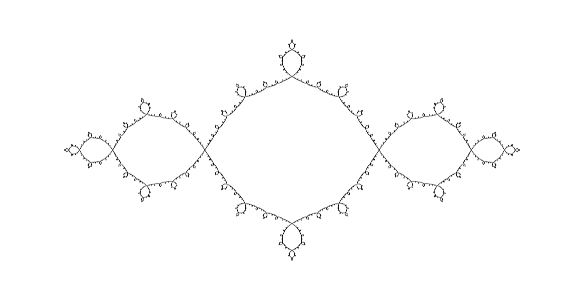

In [ ]:
plotter = DynamicsPlotter(xmin, xmax, modified_ymin, modified_ymax)
fig, ax = plotter.plot_julia_set_from_basins(basins, thickness=julia_thickness, title="", show_axis=False, show_axis_labels=False)

In [17]:
plotter.save_figure(fig, "../../figures/z_squared_minus_one_julia_set-thin.pdf")

Saved figure to: ../../figures/z_squared_minus_one_julia_set-thin.pdf


#### $P_1(z) = z^2 + 1$

In [192]:
@njit
def Rz2p1(z):
    return z**2 + 1

generate_escape_time_fractal_jitted = make_generate_escape_time_fractal_jitted(Rz2p1)

In [193]:
center = 0.0
max_distance_to_center = 2

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

attractors = np.array([0, complex(np.inf, 0)], dtype=np.complex128)

In [194]:
modified_max_iter = 256
modified_infinity_threshold=2.0

times = generate_escape_time_fractal_jitted(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=modified_max_iter, infinity_threshold=modified_infinity_threshold)

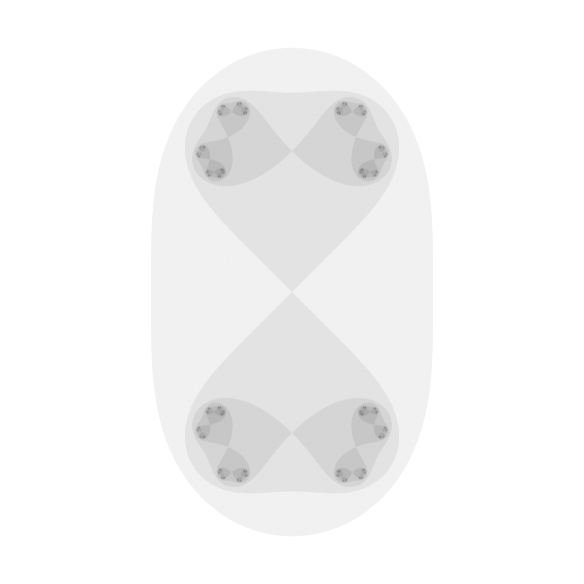

In [195]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)
fig, ax = plotter.plot_escape_time_fractal(times, title="", show_axis=False, show_axis_labels=False)

In [196]:
#plotter.save_figure(fig, "../../figures/z_squared_plus_one_escape_times.pdf")

#### $P_{c}(z) = z^2 + c$

In [244]:
c1 = -0.836 - 0.232j
c2 = 0.285 + 0.01j
c3 = -0.4 + 0.6j
c4 = -0.54 - 0.54j
c5 = - 0.12256117 + 0.74486177j

In [232]:
modified_max_iter = 128
modified_infinity_threshold=2.0

center = 0.0
max_distance_to_center = 2.0

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

##### cTest

In [233]:
cTest = -0.836 - 0.232j

def Rz2cTest(z):
    return z**2 + cTest

escape_times = generate_escape_time_fractal(xmin, xmax, ymin, ymax, 1000, 1000, Rz2cTest, max_iter=modified_max_iter, infinity_threshold=modified_infinity_threshold)

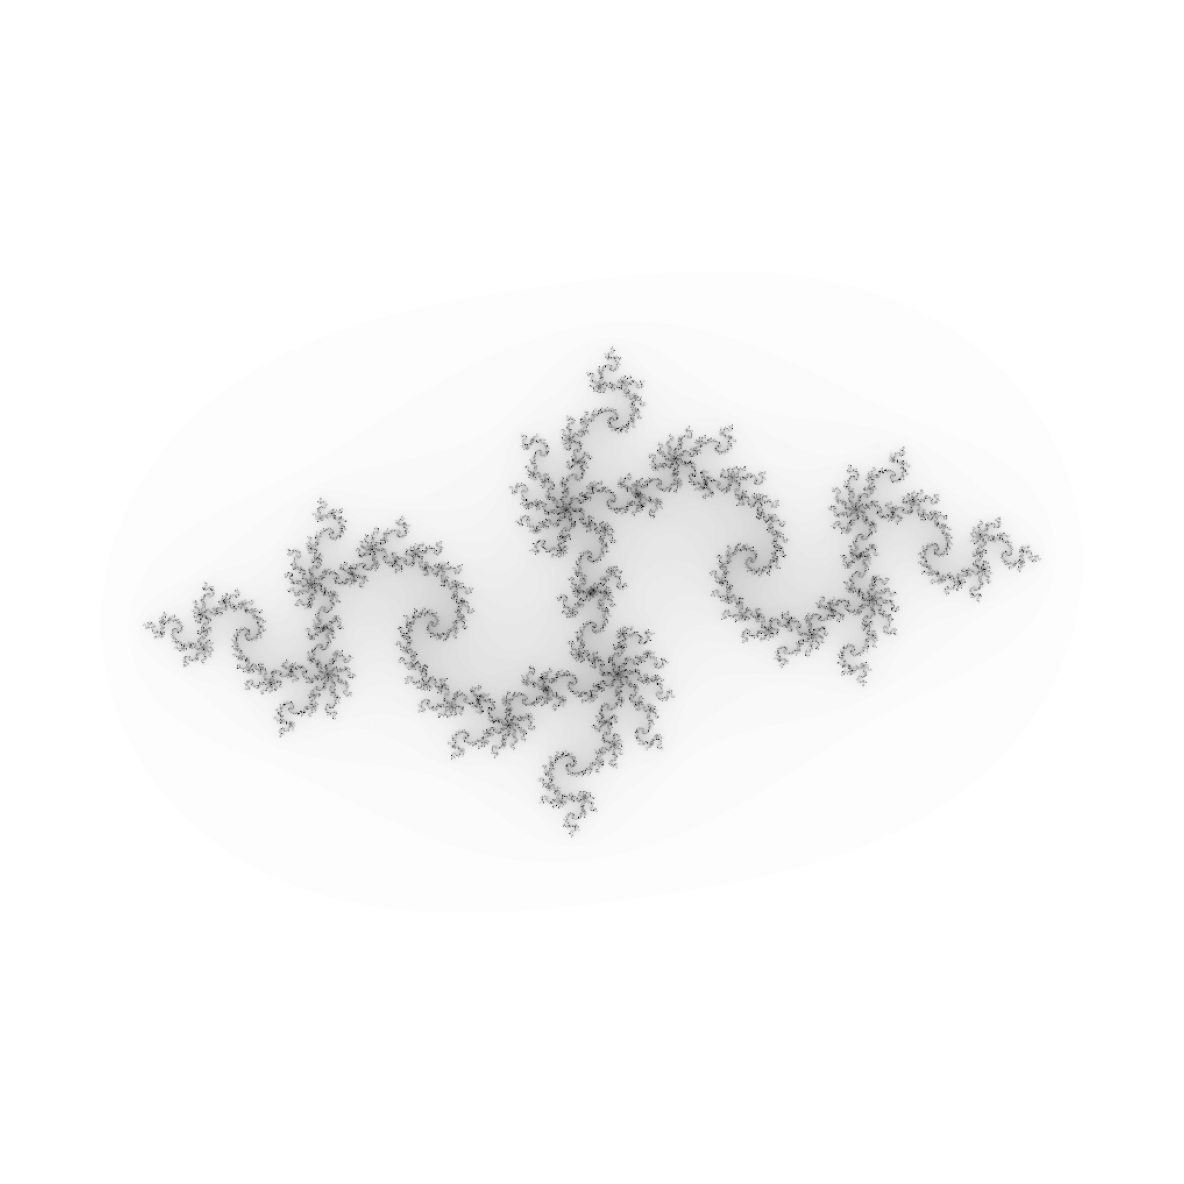

In [234]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, figsize=(12,12))
fig, ax = plotter.plot_escape_time_fractal(escape_times, title="", show_axis=False)

##### c1

In [235]:
@njit
def Rz2c1(z):
    return z**2 + c1

generate_escape_time_fractal_for_R2c1 = make_generate_escape_time_fractal_jitted(Rz2c1)

In [236]:
escape_times = generate_escape_time_fractal_for_R2c1(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=modified_max_iter, infinity_threshold=modified_infinity_threshold)

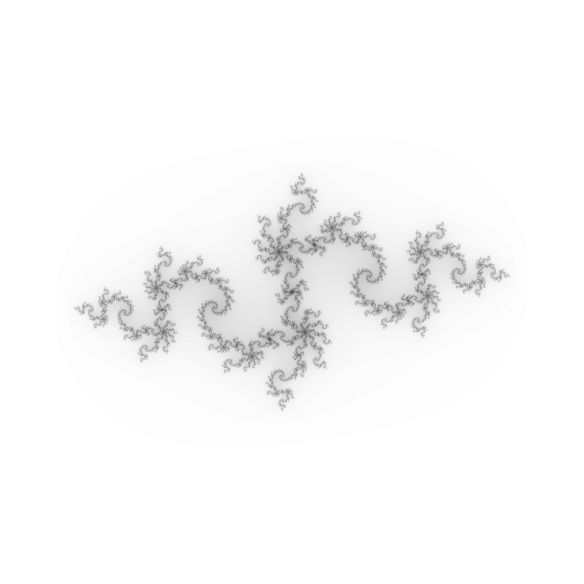

In [237]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)
fig, ax = plotter.plot_escape_time_fractal(escape_times, title="", show_axis=False)

In [238]:
plotter.save_figure(fig, "../../figures/z_squared_plus_c1_escape_times.pdf")

Saved figure to: ../../figures/z_squared_plus_c1_escape_times.pdf


##### c2

In [ ]:
@njit
def Rz2c2(z):
    return z**2 + c2

generate_escape_time_fractal_for_R2c2 = make_generate_escape_time_fractal_jitted(Rz2c2)

In [177]:
escape_times = generate_escape_time_fractal_for_R2c2(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=modified_max_iter, infinity_threshold=modified_infinity_threshold)

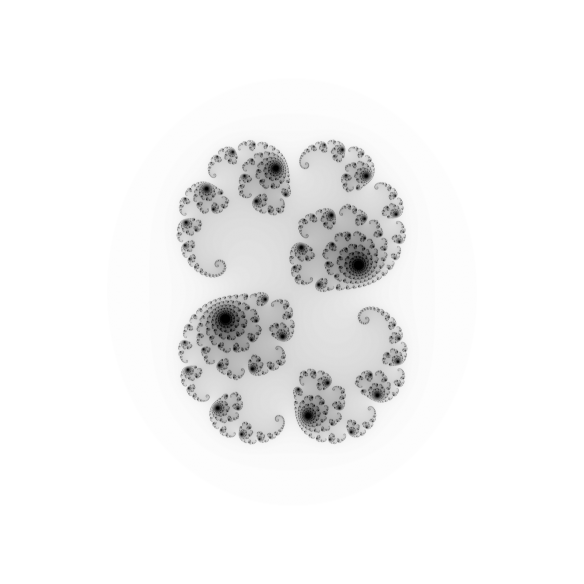

In [178]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)
fig, ax = plotter.plot_escape_time_fractal(escape_times, title="", show_axis=False)

In [179]:
plotter.save_figure(fig, "../../figures/z_squared_plus_c2_escape_times.pdf")

Saved figure to: ../../figures/z_squared_plus_c2_escape_times.pdf


##### c3

In [ ]:
@njit
def Rz2c3(z):
    return z**2 + c3

generate_escape_time_fractal_for_R2c3 = make_generate_escape_time_fractal_jitted(Rz2c3)

In [181]:
escape_times = generate_escape_time_fractal_for_R2c3(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=modified_max_iter, infinity_threshold=modified_infinity_threshold)

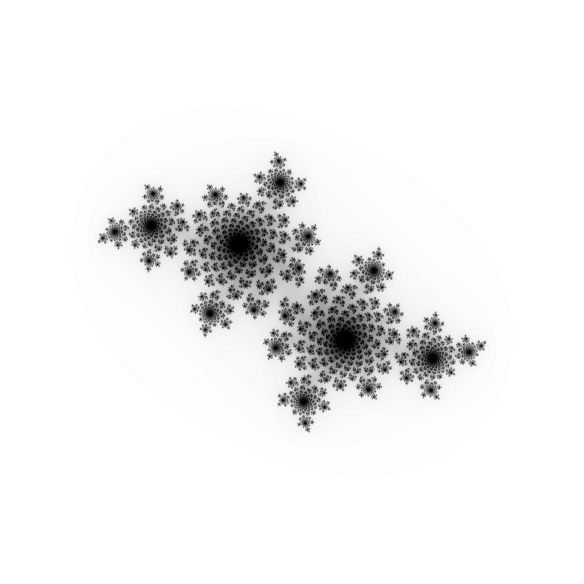

In [182]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)
fig, ax = plotter.plot_escape_time_fractal(escape_times, title="", show_axis=False)

In [183]:
plotter.save_figure(fig, "../../figures/z_squared_plus_c3_escape_times.pdf")

Saved figure to: ../../figures/z_squared_plus_c3_escape_times.pdf


##### c4

In [ ]:
@njit
def Rz2c4(z):
    return z**2 + c4

generate_escape_time_fractal_for_R2c4 = make_generate_escape_time_fractal_jitted(Rz2c4)

In [185]:
escape_times = generate_escape_time_fractal_for_R2c4(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=modified_max_iter, infinity_threshold=modified_infinity_threshold)

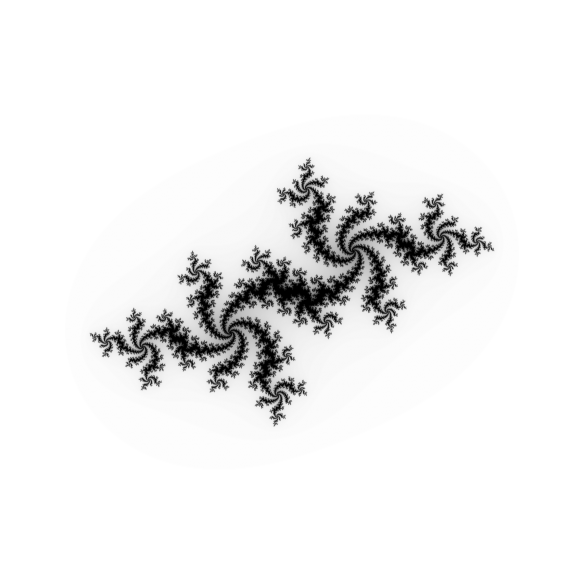

In [186]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)
fig, ax = plotter.plot_escape_time_fractal(escape_times, title="", show_axis=False)

In [187]:
plotter.save_figure(fig, "../../figures/z_squared_plus_c4_escape_times.pdf")

Saved figure to: ../../figures/z_squared_plus_c4_escape_times.pdf


##### c5

In [245]:
@njit
def Rz2c5(z):
    return z**2 + c5

generate_escape_time_fractal_for_R2c5 = make_generate_escape_time_fractal_jitted(Rz2c5)

In [246]:
escape_times = generate_escape_time_fractal_for_R2c5(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=modified_max_iter, infinity_threshold=modified_infinity_threshold)

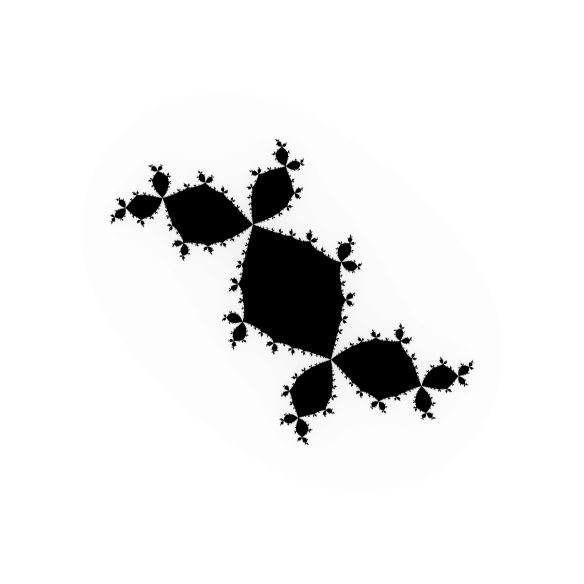

In [247]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)
fig, ax = plotter.plot_escape_time_fractal(escape_times, title="", show_axis=False)

In [248]:
plotter.save_figure(fig, "../../figures/z_squared_plus_c5_escape_times.pdf")

Saved figure to: ../../figures/z_squared_plus_c5_escape_times.pdf


#### Mandelbrot Set

In [23]:
from numba import prange

In [24]:
@njit(parallel=True)
def generate_escape_times_for_mandelbrot_set(x_min, x_max, y_min, y_max, width, height, max_iter=100, infinity_threshold=2.0):
    escape_times = np.zeros((height, width), dtype=np.int64)
    x_coords = np.linspace(x_min, x_max, width)
    y_coords = np.linspace(y_min, y_max, height)

    for i in prange(height):
        for j in range(width):
            c = complex(x_coords[j], y_coords[i])
            z = 0
            step = 0
            while step < max_iter:
                z = z*z + c
                step += 1

                if np.isinf(z.real) or np.isinf(z.imag) or np.isnan(z.real) or np.isnan(z.imag) or abs(z) > infinity_threshold:
                    break

            escape_times[i, j] = step

    return escape_times

In [107]:
center = -0.75
max_distance_to_center = 1.4

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

modified_max_iter = 100
modified_infinity_threshold=max((max_distance_to_center + abs(center))*2, 2)

escape_times_mandelbrot = generate_escape_times_for_mandelbrot_set(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=modified_max_iter, infinity_threshold=modified_infinity_threshold)

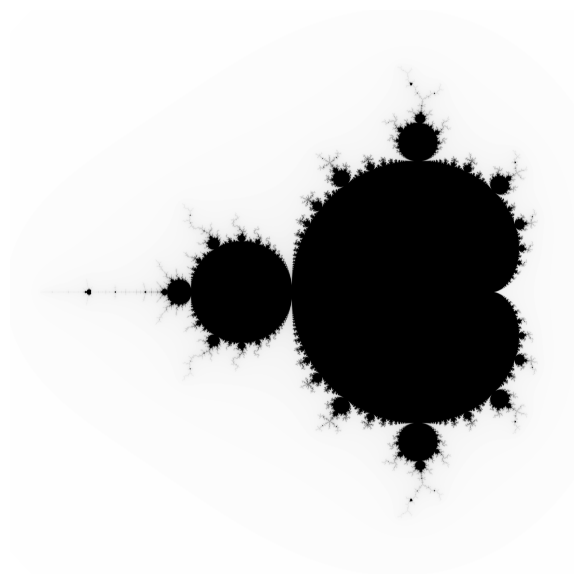

In [108]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)
fig, ax = plotter.plot_escape_time_fractal(escape_times_mandelbrot, cmap="Grays", title="", show_axis=False)

In [109]:
plotter.save_figure(fig, "../../figures/mandelbrot_set.pdf")

Saved figure to: ../../figures/mandelbrot_set.pdf


In [ ]:
modified_max_iter = 256
modified_infinity_threshold=max((max_distance_to_center + abs(center))*2, 2)

escape_times_mandelbrot = generate_escape_times_for_mandelbrot_set(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=modified_max_iter, infinity_threshold=modified_infinity_threshold)

In [95]:
@njit(parallel=True)
def round_escape_times_for_mandelbrot_set(escape_times_mandelbrot, width, height, frac=0.25, max_iter=100):
    escape_times_mandelbrot_rounded = np.zeros((horizontal_pixels, vertical_pixels), dtype=np.int64)

    for y in prange(vertical_pixels):
        for x in range(horizontal_pixels):
            if escape_times_mandelbrot[y, x] >= modified_max_iter*frac:
                escape_times_mandelbrot_rounded[y, x] = 1
            else:
                escape_times_mandelbrot_rounded[y, x] = 0

    return escape_times_mandelbrot_rounded

In [102]:
escape_times_mandelbrot_rounded = round_escape_times_for_mandelbrot_set(escape_times_mandelbrot, horizontal_pixels, vertical_pixels, frac=0.125, max_iter=modified_max_iter)

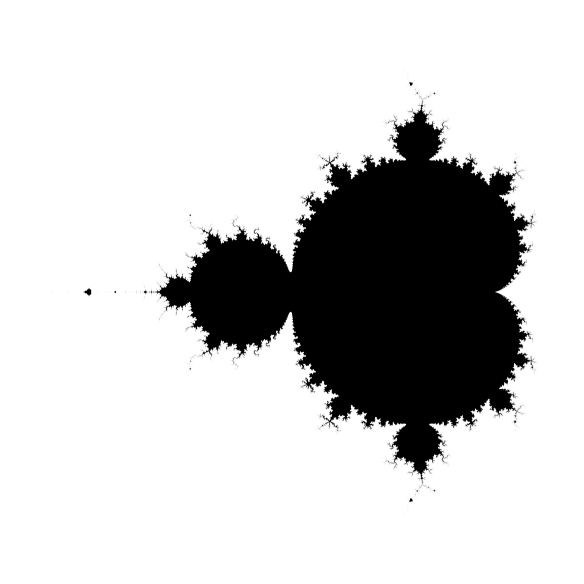

In [104]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)
fig, ax = plotter.plot_escape_time_fractal(escape_times_mandelbrot_rounded, title="", show_axis=False)

In [105]:
plotter.save_figure(fig, "../../figures/mandelbrot_set-binary.pdf")

Saved figure to: ../../figures/mandelbrot_set-binary.pdf


## Section 3: El Método de Newton

### $P(z) = z^2 - 1$

In [13]:
z = sp.symbols('z', complex=True)

P = z**2 - 1
print("P:")
print(P)
print()

P_prime = P.diff(z)
print("P':")
print(P_prime)
print()

print("Np(z):")
print(rf"z - ({P})/({P_prime})")

P:
z**2 - 1

P':
2*z

Np(z):
z - (z**2 - 1)/(2*z)


In [ ]:
@njit
def Nz2m1(z):
    return z - (z**2 - 1)/(2*z)

generate_fatou_basins_and_times_for_Nz2m1 = make_generate_fatou_basins_and_times_jitted(Nz2m1)

In [21]:
center = 0.0
max_distance_to_center = 4

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

attractors = np.array([1, -1], dtype=np.complex128)

In [ ]:
basins, times = generate_fatou_basins_and_times_for_Nz2m1(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, attractors, max_iter=max_iter, tolerance=tolerance, infinity_threshold=infinity_threshold)

<Axes: >

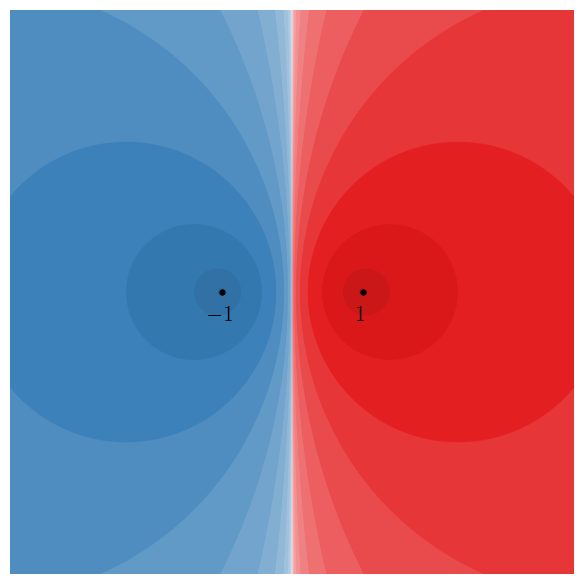

In [23]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_fatou_basins_shaded(basins, times, title="", show_axis=False)
plotter.add_points(ax, [1], label="$1$")
plotter.add_points(ax, [-1], label="$-1$")

In [25]:
plotter.save_figure(fig, "../../figures/z_squared_minus_one_newton_fatou_basins_and_times.pdf")

Saved figure to: ../../figures/z_squared_minus_one_newton_fatou_basins_and_times.pdf


### $P(z) = z^3 - 1$

In [26]:
z = sp.symbols('z', complex=True)

P = z**3 - 1
print("P:")
print(P)
print()

P_prime = P.diff(z)
print("P':")
print(P_prime)
print()

print("Np(z):")
print(rf"z - ({P})/({P_prime})")
print()

roots = sp.roots(P, z)
print("Roots:")
print(roots)
print

P:
z**3 - 1

P':
3*z**2

Np(z):
z - (z**3 - 1)/(3*z**2)

Roots:
{1: 1, -1/2 - sqrt(3)*I/2: 1, -1/2 + sqrt(3)*I/2: 1}


<function print>

In [27]:
@njit
def Nz3m1(z):
    return z - (z**3 - 1)/(3*z**2)

generate_fatou_basins_and_times_for_Nz3m1 = make_generate_fatou_basins_and_times_jitted(Nz3m1)

In [31]:
center = 0.0
max_distance_to_center = 2

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

attractors = np.array([1, complex(-1/2, + np.sqrt(3)/2), complex(-1/2, - np.sqrt(3)/2)], dtype=np.complex128)

In [34]:
basins, times = generate_fatou_basins_and_times_for_Nz3m1(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, attractors, max_iter=max_iter, tolerance=tolerance, infinity_threshold=infinity_threshold)

<Axes: >

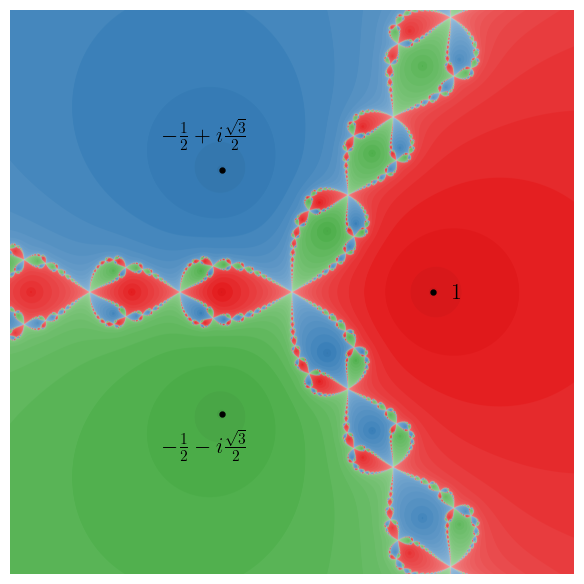

In [38]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_fatou_basins_shaded(basins, times, shading_power=0.25, title="", show_axis=False)
plotter.add_points(ax, [1], label="$1$", text_offset=(18, 6))
plotter.add_points(ax, [complex(-1/2, + np.sqrt(3)/2)], label=r"$-\frac{1}{2} + i\frac{\sqrt{3}}{2}$", text_offset=(-12, 36))
plotter.add_points(ax, [complex(-1/2, - np.sqrt(3)/2)], label=r"$-\frac{1}{2} - i\frac{\sqrt{3}}{2}$", text_offset=(-12, -12))

In [39]:
plotter.save_figure(fig, "../../figures/z_cubed_minus_one_newton_fatou_basins_and_times.pdf")

Saved figure to: ../../figures/z_cubed_minus_one_newton_fatou_basins_and_times.pdf


### $P(z) = z^4 - 1$

In [14]:
z = sp.symbols('z', complex=True)

P = z**4 - 1
print("P:")
print(P)
print()

P_prime = P.diff(z)
print("P':")
print(P_prime)
print()

print("Np(z):")
print(rf"z - ({P})/({P_prime})")
print()

roots = sp.roots(P, z)
print("Roots:")
print(roots)
print

P:
z**4 - 1

P':
4*z**3

Np(z):
z - (z**4 - 1)/(4*z**3)

Roots:
{-1: 1, 1: 1, -I: 1, I: 1}


<function print>

In [15]:
@njit
def Nz4m1(z):
    return z - (z**4 - 1)/(4*z**3)

generate_fatou_basins_and_times_for_Nz4m1 = make_generate_fatou_basins_and_times_jitted(Nz4m1)

In [16]:
center = 0.0
max_distance_to_center = 4

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

attractors = np.array([1, 1j, -1, -1j], dtype=np.complex128)

In [17]:
basins, times = generate_fatou_basins_and_times_for_Nz4m1(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, attractors, max_iter=max_iter, tolerance=tolerance, infinity_threshold=infinity_threshold)

<Axes: >

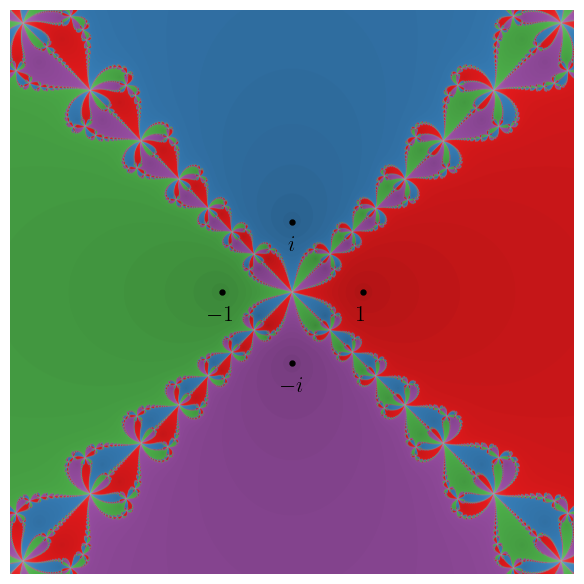

In [18]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_fatou_basins_shaded(basins, times, shading_power=0.3, title="", show_axis=False)
plotter.add_points(ax, [1], label="$1$")
plotter.add_points(ax, [-1], label="$-1$")
plotter.add_points(ax, [1j], label="$i$")
plotter.add_points(ax, [-1j], label="$-i$")

In [19]:
plotter.save_figure(fig, "../../figures/z_forth_minus_one_newton_fatou_basins_and_times.pdf")

Saved figure to: ../../figures/z_forth_minus_one_newton_fatou_basins_and_times.pdf


### $P(z) = z^5 - 1$

In [20]:
z = sp.symbols('z', complex=True)

P = z**5 - 1
print("P:")
print(P)
print()

P_prime = P.diff(z)
print("P':")
print(P_prime)
print()

print("Np(z):")
print(rf"z - ({P})/({P_prime})")
print()

roots = sp.roots(P, z)
print("Roots:")
print(roots)
print()

for root in roots:
    print(root)

P:
z**5 - 1

P':
5*z**4

Np(z):
z - (z**5 - 1)/(5*z**4)

Roots:
{1: 1, -sqrt(5)/4 - 1/4 - I*sqrt(5/8 - sqrt(5)/8): 1, -sqrt(5)/4 - 1/4 + I*sqrt(5/8 - sqrt(5)/8): 1, -1/4 + sqrt(5)/4 - I*sqrt(sqrt(5)/8 + 5/8): 1, -1/4 + sqrt(5)/4 + I*sqrt(sqrt(5)/8 + 5/8): 1}

1
-sqrt(5)/4 - 1/4 - I*sqrt(5/8 - sqrt(5)/8)
-sqrt(5)/4 - 1/4 + I*sqrt(5/8 - sqrt(5)/8)
-1/4 + sqrt(5)/4 - I*sqrt(sqrt(5)/8 + 5/8)
-1/4 + sqrt(5)/4 + I*sqrt(sqrt(5)/8 + 5/8)


In [21]:
@njit
def Nz5m1(z):
    return z - (z**5 - 1)/(5*z**4)

generate_fatou_basins_and_times_for_Nz5m1 = make_generate_fatou_basins_and_times_jitted(Nz5m1)

In [22]:
center = 0.0
max_distance_to_center = 4

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

attractors = np.array(
    [
        1,
        complex(-1/4 + np.sqrt(5)/4, np.sqrt(np.sqrt(5)/8 + 5/8)),
        complex(-np.sqrt(5)/4 - 1/4, np.sqrt(5/8 - np.sqrt(5)/8)),
        complex(-np.sqrt(5)/4 - 1/4, -np.sqrt(5/8 - np.sqrt(5)/8)),
        complex(-1/4 + np.sqrt(5)/4, -np.sqrt(np.sqrt(5)/8 + 5/8))
    ],
    dtype=np.complex128
)

In [23]:
basins, times = generate_fatou_basins_and_times_for_Nz5m1(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, attractors, max_iter=max_iter, tolerance=tolerance, infinity_threshold=infinity_threshold)

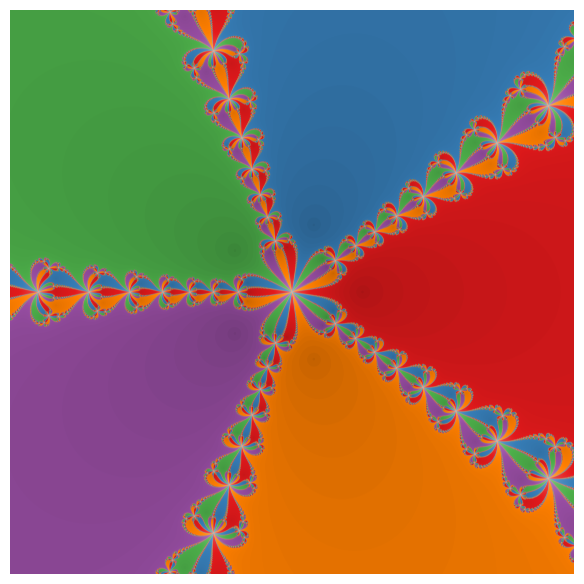

In [24]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_fatou_basins_shaded(basins, times, shading_power=0.3, title="", show_axis=False)

In [25]:
plotter.save_figure(fig, "../../figures/z_fifth_minus_one_newton_fatou_basins_and_times.pdf")

Saved figure to: ../../figures/z_fifth_minus_one_newton_fatou_basins_and_times.pdf
